In [1]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

sql = '''
select 
r.id,
c.name as ligand,
r.protein_concentration,
w.volume,
dispense_assay_mix,
dispense_ligands,
centrifuge_minutes,
centrifuge_rpm,
protein_days_thawed,
r.km,
r.vmax,
r.r_squared,
group_concat(distinct ra.comment) as comments,
r.locked,
r.accepted,
e.id as experiment_id

from result r
left join wellresultlink wr
on r.id = wr.result_id
left join well w
on wr.well_id = w.id
left join resultannotation ra
on r.id = ra.result_id
left join compound c
on c.id = r.compound_id
left join experiment e
on e.id = r.experiment_id
where 
locked = 1 
and 
accepted = 1
group by r.id
order by r.id
'''

with sqlite3.connect('../api/database.db') as con:
    df = pd.read_sql(sql, con)
df

,id,ligand,protein_concentration,volume,dispense_assay_mix,dispense_ligands,centrifuge_minutes,centrifuge_rpm,protein_days_thawed,km,vmax,r_squared,comments,locked,accepted,experiment_id
0,3,Lauric Acid,8.83,50.0,electronic_multichannel_pipette,serial_dilution,0,0,NaN,9.401697e+01,0.025695,0.708569,No Response,1,1,3
1,4,Lauric Acid,8.83,50.0,electronic_multichannel_pipette,serial_dilution,0,0,NaN,2.040425e+03,0.169997,0.967134,No Response,1,1,3
2,5,Lauric Acid,8.83,50.0,electronic_multichannel_pipette,serial_dilution,0,0,NaN,1.925689e+03,0.224193,0.992758,No Response,1,1,3
3,6,Lauric Acid,8.83,50.0,electronic_multichannel_pipette,serial_dilution,0,0,NaN,2.293340e+03,0.275000,0.938360,None,1,1,3
4,7,Lauric Acid,8.83,50.0,electronic_multichannel_pipette,serial_dilution,0,0,NaN,3.950073e+02,0.063840,0.947681,No Response,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
587,1031,Arachadionic acid,4.05,40.0,Clariostar Injector,echo,2,3700,0.0,2.780295e+01,0.089972,0.996732,None,1,1,21
588,1032,Arachadionic acid,4.05,40.0,Clariostar Injector,echo,2,3700,0.0,3.295857e+01,0.087556,0.996419,None,1,1,21
589,1033,Arachadionic acid,4.05,40.0,Clariostar Injector,echo,2,3700,0.0,3.028905e+01,0.089834,0.990017,None,1,1,21
590,1034,Arachadionic acid,4.05,40.0,Clariostar Injector,echo,2,3700,0.0,3.213957e+01,0.090391,0.996734,None,1,1,21


In [13]:
output = []
for (ligand ), data in df.groupby(['ligand']):
    for (dispense_ligands, dispense_assay_mix, volume, experiment_id, protein_concentration), data_ in data.groupby(['dispense_ligands', 
                                                                               'dispense_assay_mix',
                                                                               'volume',
                                                                               'experiment_id',
                                                                               'protein_concentration'
                                                                              ]):
        output.append({'ligand': ligand, 
                       'dispense_ligands': dispense_ligands, 
                       'dispense_assay_mix': dispense_assay_mix,
                       'volume': volume,
                       'km_median': data_['km'].median(),
                       'km_std':  data_['km'].std(),
                       'vmax_median': data_['vmax'].median(),
                       'vmax_std':  data_['vmax'].std(),
                       'rsq_median': data_['r_squared'].median(),
                       'rsq_std':  data_['r_squared'].std(),
                       'count': len(data_),
                       'experiment_id': experiment_id,
                       'protein_concentration': protein_concentration
                      })

output = pd.DataFrame(output).sort_values(['ligand', 'experiment_id'])
validation_experiments = [
    11
]
output_serial = output.loc[output['experiment_id'].isin(validation_experiments), :]
output_serial = output_serial.loc[output_serial['volume'] == 50, :].dropna()
print(output_serial[['ligand', 'km_median', 'km_std', 'vmax_median', 'vmax_std', 'rsq_median', 'rsq_std', 'count']].sort_values(['ligand']).to_markdown(index=False, floatfmt="0.2f"))

| ligand            |   km_median |   km_std |   vmax_median |   vmax_std |   rsq_median |   rsq_std |   count |
|:------------------|------------:|---------:|--------------:|-----------:|-------------:|----------:|--------:|
| 4-Phenylimidazole |       36.50 |   150.39 |          0.01 |       0.01 |         0.69 |      0.36 |       4 |
| Arachadionic Acid |       30.13 |    26.15 |          0.27 |       0.10 |         0.82 |      0.04 |       3 |
| Lauric Acid       |       68.64 |     7.26 |          0.06 |       0.00 |         0.93 |      0.01 |       5 |
| Palmitic Acid     |        2.58 |     0.51 |          0.11 |       0.01 |         0.90 |      0.01 |       2 |


/tmp/ipykernel_3018168/711191998.py:2: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for (ligand ), data in df.groupby(['ligand']):


In [15]:
output_echo = output.loc[output['experiment_id'].isin([15]), :]
output_echo = output_echo.loc[output_echo['volume'] == 30, :].dropna()
output_echo = output_echo.loc[output_echo['protein_concentration'] > 8.45, :]
print(output_echo[['ligand', 'km_median', 'km_std', 'vmax_median', 'vmax_std', 'rsq_median', 'rsq_std', 'count']].sort_values(['ligand']).to_markdown(index=False, floatfmt="0.2f"))

| ligand            |   km_median |   km_std |   vmax_median |   vmax_std |   rsq_median |   rsq_std |   count |
|:------------------|------------:|---------:|--------------:|-----------:|-------------:|----------:|--------:|
| 4-Phenylimidazole |       15.07 |    45.43 |          0.01 |       0.01 |         0.25 |      0.25 |       5 |
| Arachadionic acid |      100.37 |    32.41 |          0.22 |       0.12 |         0.97 |      0.18 |       3 |
| DMSO              |        8.63 |   179.24 |          0.02 |       0.03 |         0.51 |      0.35 |       8 |
| Lauric acid       |       27.90 |    26.36 |          0.01 |       0.02 |         0.52 |      0.24 |       8 |
| Palmitic acid     |        9.59 |    94.40 |          0.01 |       0.01 |         0.54 |      0.20 |       8 |
| SDS               |       22.77 |    43.55 |          0.01 |       0.03 |         0.58 |      0.21 |       8 |


Titration Mean km = 120.61 std = 20.09
Plate Assay Mean km = 120.61 std = 20.09


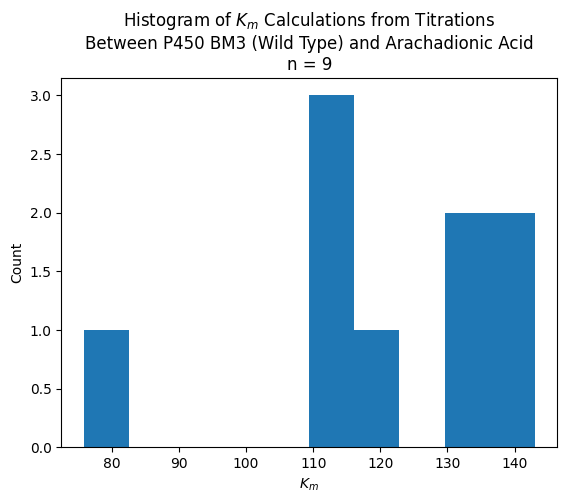

In [4]:
df_titration = pd.read_csv('titration_mm.csv')
df_titration_aa = df_titration.query('ligand == "Arachadonic Acid"')

print(f'Titration Mean km = {df_titration_aa["km"].mean():.2f} std = {df_titration_aa["km"].std():.2f}')
print(f'Plate Assay Mean km = {df_titration_aa["km"].mean():.2f} std = {df_titration_aa["km"].std():.2f}')

plt.hist(df_titration_aa['km'],
        bins=10)
plt.xlabel('$K_m$')
plt.ylabel('Count')
plt.title(f'Histogram of $K_m$ Calculations from Titrations\nBetween P450 BM3 (Wild Type) and Arachadionic Acid\nn = {len(df_titration_aa)}')
plt.show()

In [5]:
df.query('ligand == "Arachadionic Acid" ')['dispense_ligands'].value_counts()

serial_dilution    67
Name: dispense_ligands, dtype: int64

In [6]:
df['ligand'].value_counts()

Arachadionic acid    169
Arachadionic Acid    102
Lauric acid           62
4-Phenylimidazole     60
Lauric Acid           56
Palmitic Acid         54
Palmitic acid         37
SDS                   14
DMSO                  13
Buffer Only            2
Protein Only           2
Name: ligand, dtype: int64

km mean = 65.13 std = 63.14


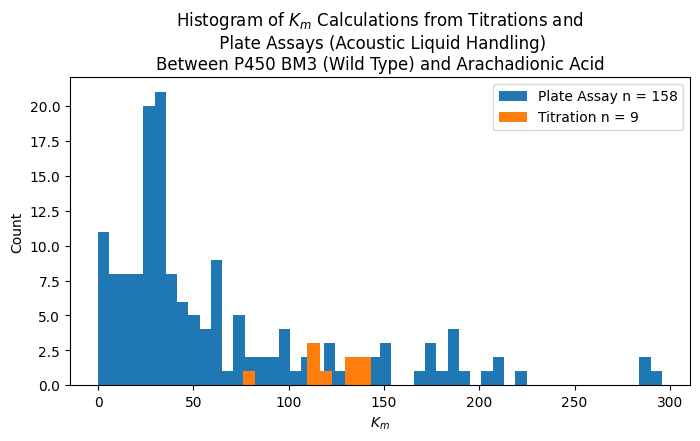

In [7]:
aa_echo = df.query('dispense_ligands == "echo"')
aa_echo = aa_echo.loc[aa_echo['ligand'].str.contains('arachadionic', case=False), :]

print(f"km mean = {aa_echo['km'].mean():.2f} std = {aa_echo['km'].std():.2f}")


plt.figure(figsize=(8, 4))
plt.hist(aa_echo['km'], bins=50, label=f'Plate Assay n = {len(aa_echo)}')
plt.hist(df_titration_aa['km'], bins=10, label=f'Titration n = {len(df_titration_aa)}')
plt.title(f'Histogram of $K_m$ Calculations from Titrations and\n Plate Assays (Acoustic Liquid Handling)\nBetween P450 BM3 (Wild Type) and Arachadionic Acid')

plt.xlabel('$K_m$')
plt.ylabel('Count')
plt.legend()
plt.savefig(os.path.join('accuracy', 'hist-arachadionic-acid-echo-titration.png'))
plt.show()

km mean = 30.19 std = 45.83


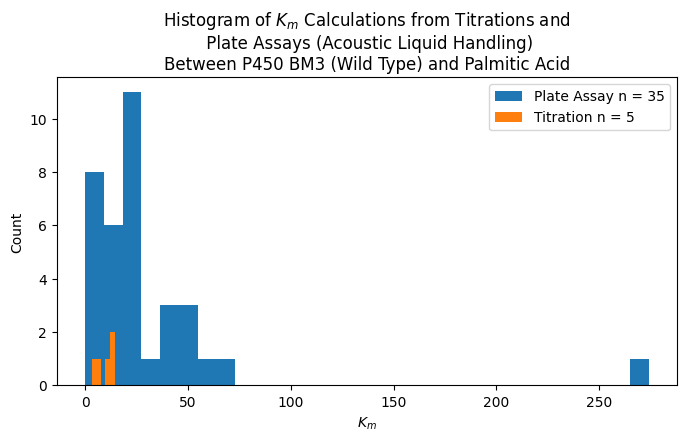

In [8]:
pa_echo = df.query('dispense_ligands == "echo"')
pa_echo = pa_echo.loc[pa_echo['ligand'].str.contains('palm', case=False), :]

df_titration_pa = df_titration.query('ligand == "Palmitic Acid"')

print(f"km mean = {pa_echo['km'].mean():.2f} std = {pa_echo['km'].std():.2f}")


plt.figure(figsize=(8, 4))
plt.hist(pa_echo['km'], bins=30, label=f'Plate Assay n = {len(pa_echo)}')
plt.hist(df_titration_pa['km'], bins=5, label=f'Titration n = {len(df_titration_pa)}')
plt.title(f'Histogram of $K_m$ Calculations from Titrations and\n Plate Assays (Acoustic Liquid Handling)\nBetween P450 BM3 (Wild Type) and Palmitic Acid')

plt.xlabel('$K_m$')
plt.ylabel('Count')
plt.legend()
plt.savefig(os.path.join('accuracy', 'hist-palmitic-acid-echo-titration.png'))
plt.show()

km mean = 189.06 std = 429.50


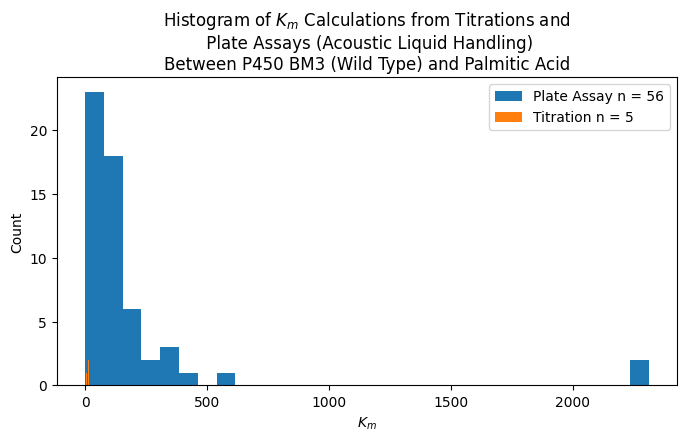

In [9]:
## pa_echo = df.query('dispense_ligands == "serial_dilution"')
pa_echo = pa_echo.loc[~pa_echo['ligand'].isna(), :]
pa_echo = pa_echo.loc[pa_echo['ligand'].str.contains('palm', case=False), :]

print(f"km mean = {pa_echo['km'].mean():.2f} std = {pa_echo['km'].std():.2f}")


plt.figure(figsize=(8, 4))
plt.hist(pa_echo['km'], bins=30, label=f'Plate Assay n = {len(pa_echo)}')
plt.hist(df_titration_pa['km'], bins=5, label=f'Titration n = {len(df_titration_pa)}')
plt.title(f'Histogram of $K_m$ Calculations from Titrations and\n Plate Assays (Acoustic Liquid Handling)\nBetween P450 BM3 (Wild Type) and Palmitic Acid')

plt.xlabel('$K_m$')
plt.ylabel('Count')
plt.legend()
plt.savefig(os.path.join('accuracy', 'hist-palmitic-acid-serial-titration.png'))
plt.show()


km mean = 32.35 std = 21.06


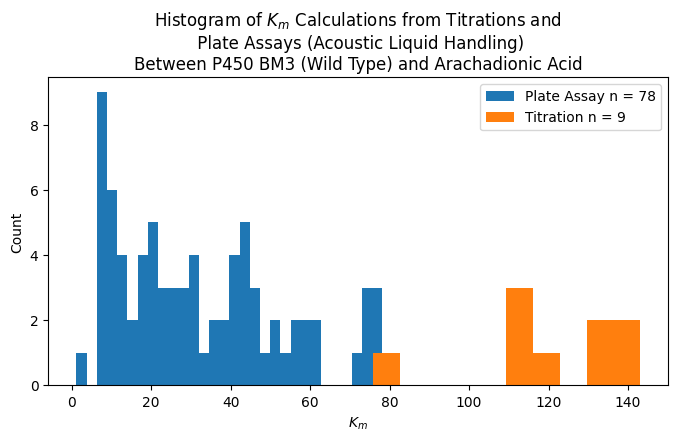

In [10]:
aa_serial = df.query('dispense_ligands == "serial_dilution"')
aa_serial = aa_serial.loc[~aa_serial['ligand'].isna(), :]
aa_serial = aa_serial.loc[aa_serial['ligand'].str.contains('arachadionic', case=False), :]

print(f"km mean = {aa_serial['km'].mean():.2f} std = {aa_serial['km'].std():.2f}")


plt.figure(figsize=(8, 4))
plt.hist(aa_serial['km'], bins=30, label=f'Plate Assay n = {len(aa_serial)}')
plt.hist(df_titration_aa['km'], bins=10, label=f'Titration n = {len(df_titration_aa)}')
plt.title(f'Histogram of $K_m$ Calculations from Titrations and\n Plate Assays (Acoustic Liquid Handling)\nBetween P450 BM3 (Wild Type) and Arachadionic Acid')

plt.xlabel('$K_m$')
plt.ylabel('Count')
plt.legend()
plt.savefig(os.path.join('accuracy', 'hist-arachadionic-acid-serial-titration.png'))
plt.show()

km mean = 65.13 std = 63.14


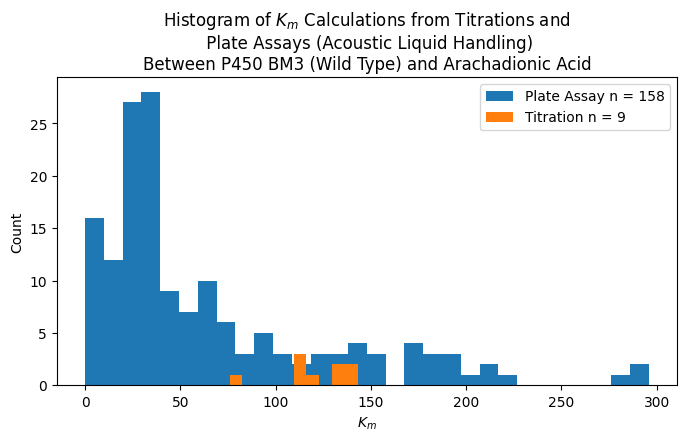

In [11]:
aa_serial = df.query('ligand == "Arachadionic Acid"')

print(f"km mean = {aa_echo['km'].mean():.2f} std = {aa_echo['km'].std():.2f}")


plt.figure(figsize=(8, 4))
plt.hist(aa_echo['km'], bins=30, label=f'Plate Assay n = {len(aa_echo)}')
plt.hist(df_titration_aa['km'], bins=10, label=f'Titration n = {len(df_titration_aa)}')
plt.title(f'Histogram of $K_m$ Calculations from Titrations and\n Plate Assays (Acoustic Liquid Handling)\nBetween P450 BM3 (Wild Type) and Arachadionic Acid')

plt.xlabel('$K_m$')
plt.ylabel('Count')
plt.legend()
plt.savefig(os.path.join('accuracy', 'hist-arachadionic-acid-echo-titration.png'))
plt.show()


,file,ligand,vmax,km,r_squared,experiment_number
0,./19_Validation/TitrationData/20191204_Lauric_...,Lauric Acid,0.044889,1.366392e+03,0.987644,19
1,./19_Validation/TitrationData/20191204_Lauric_...,Lauric Acid,0.057109,1.619429e+03,0.995141,19
2,./19_Validation/TitrationData/20191204_Lauric_...,Lauric Acid,0.049522,1.578336e+03,0.991451,19
3,./19_Validation/TitrationData/20191204_Lauric_...,Lauric Acid,0.055193,2.305610e+03,0.985535,19
4,./19_Validation/TitrationData/20191204_Lauric_...,Lauric Acid,0.042295,1.399288e+03,0.975691,19
5,./13_TitrationValidationPilot/20191010_test/ti...,Lauric Acid,0.007107,1.428215e-12,-0.414488,13
6,./13_TitrationValidationPilot/20191010_test/ti...,Lauric Acid,0.034889,7.849218e+02,0.888948,13
7,./19_Validation/TitrationData/20191128_Palmiti...,Palmitic Acid,0.189689,6.994394e+00,0.969935,19
8,./19_Validation/TitrationData/20191128_Palmiti...,Palmitic Acid,0.193934,1.308247e+01,0.995387,19
9,./19_Validation/TitrationData/20191128_Palmiti...,Palmitic Acid,0.160646,9.968652e+00,0.915768,19


0           Lauric Acid
1           Lauric Acid
2           Lauric Acid
3           Lauric Acid
4           Lauric Acid
5           Lauric Acid
6           Lauric Acid
7         Palmitic Acid
8         Palmitic Acid
9         Palmitic Acid
10        Palmitic Acid
11        Palmitic Acid
12    Arachadionic Acid
13    Arachadionic Acid
14    Arachadionic Acid
15    Arachadionic Acid
16    Arachadionic Acid
17    Arachadionic Acid
18    Arachadionic Acid
19    Arachadionic Acid
20    Arachadionic Acid
21    4-Phenylimidazole
22    4-Phenylimidazole
23    4-Phenylimidazole
24    4-Phenylimidazole
25    4-Phenylimidazole
Name: ligand, dtype: object

In [56]:
ligand

'Palmitic Acid'

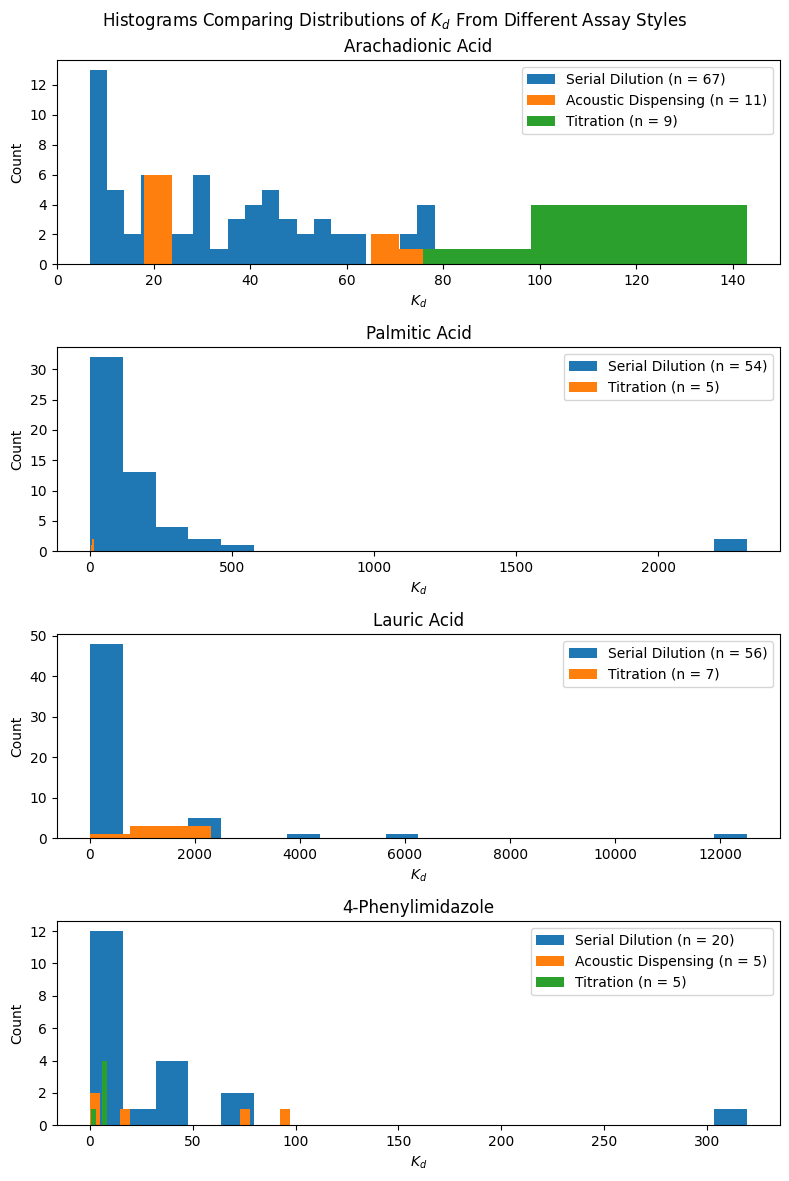

In [75]:
df_titration['ligand'] = df_titration['ligand'].str.replace('Arachadonic', 'Arachadionic')

ligand_names = [
    "Arachadionic Acid",
    "Palmitic Acid",
    "Lauric Acid",
    "4-Phenylimidazole",
              ]

fig, axs = plt.subplots(len(ligand_names), 1, figsize=(8, 3 * len(ligand_names)))

for ligand, ax in zip(ligand_names, axs):
    ligand_df = df.query(f'ligand == "{ligand}"')
    
    ligand_df_serial = ligand_df.query('dispense_ligands == "serial_dilution" & volume == 50')
    if len(ligand_df_serial) > 0:
        ax.hist(ligand_df_serial['km'], label=f"Serial Dilution (n = {len(ligand_df_serial)})", bins=20)
    
    ligand_df_echo = ligand_df.query('dispense_ligands != "serial_diltuion" & volume == 30')
    if len(ligand_df_echo) > 0:
        ax.hist(ligand_df_echo['km'], label=f"Acoustic Dispensing (n = {len(ligand_df_echo)})", bins=20)

    ligand_df_titration = df_titration.query(f'ligand == "{ligand}"')
    if len(ligand_df_titration) > 0:
        ax.hist(ligand_df_titration['km'], label=f"Titration (n = {len(ligand_df_titration)})", bins=3)

    ax.legend()
    ax.set_title(f'{ligand}')
    ax.set_xlabel('$K_d$')
    ax.set_ylabel('Count')

fig.suptitle("Histograms Comparing Distributions of $K_d$ From Different Assay Styles")
plt.tight_layout()
plt.savefig(os.path.join('accuracy', 'histograms-all-ligands.png'))
plt.show()

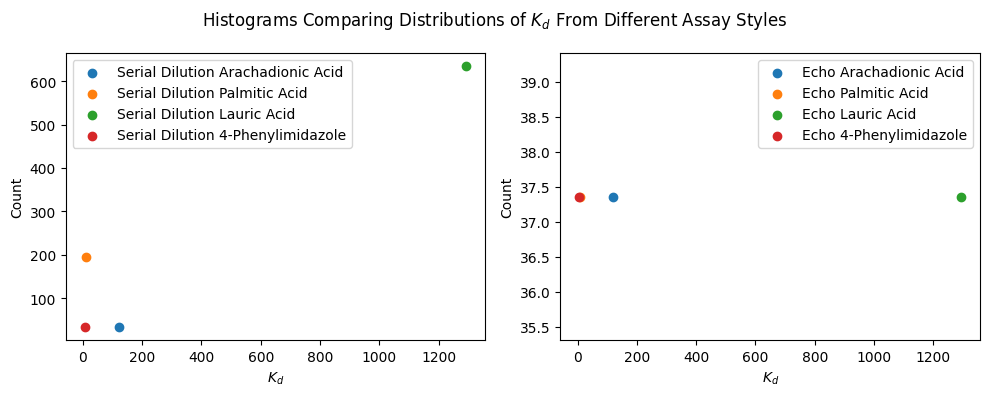

In [76]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

for ligand in ligand_names:
    ligand_df = df.query(f'ligand == "{ligand}"')
    
    ligand_df_titration = df_titration.query(f'ligand == "{ligand}"')
    ligand_df_serial = ligand_df.query('dispense_ligands == "serial_dilution" & volume == 50')
    axs[0].scatter(
        ligand_df_titration['km'].mean(),
        ligand_df_serial['km'].mean(),
               label=f"Serial Dilution {ligand}"
    )
    
    axs[1].scatter(
        ligand_df_titration['km'].mean(),
        ligand_df_echo['km'].mean(), 
               label=f"Echo {ligand}"
              )
    


#axs[0].set_title(f'{ligand}')
axs[0].set_xlabel('$K_d$')
axs[0].set_ylabel('$K_d$')
axs[0].legend()

#axs[1].set_title(f'{ligand}')
axs[1].set_xlabel('$K_d$')
axs[1].set_ylabel('$K_d$')
axs[1].legend()

fig.suptitle("Histograms Comparing Distributions of $K_d$ From Different Assay Styles")
plt.tight_layout()
#plt.savefig(os.path.join('accuracy', 'histograms-all-ligands.png'))
plt.show()

In [129]:
titration_medians = df_titration.groupby('ligand').median()['km']

x_serial = pd.Series(output_serial['km_median'].to_list(), index=output_serial['ligand'].to_list(), name='Median Kd Serial Dispensing')
x_echo = pd.Series(output_echo['km_median'].to_list(), index=output_echo['ligand'].str.title().to_list(), name='Median Kd Acoustic Dispensing')
x_titration = pd.Series(titration_medians.to_list(), index=titration_medians.index, name='Titration')

x = pd.concat([x_serial, x_echo, x_titration], axis=1).dropna()
print(x.to_markdown(floatfmt='0.2f'))

|                   |   Median Kd Serial Dispensing |   Median Kd Acoustic Dispensing |   Titration |
|:------------------|------------------------------:|--------------------------------:|------------:|
| 4-Phenylimidazole |                         36.50 |                           15.07 |        6.73 |
| Arachadionic Acid |                         30.13 |                          100.37 |      118.71 |
| Lauric Acid       |                         68.64 |                           27.90 |     1399.29 |
| Palmitic Acid     |                          2.58 |                            9.59 |        9.97 |


/tmp/ipykernel_3018168/913254601.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  titration_medians = df_titration.groupby('ligand').median()['km']


In [125]:
x_echo.index.str.title()

Index(['4-Phenylimidazole', 'Arachadionic Acid', 'Dmso', 'Lauric Acid',
       'Palmitic Acid', 'Sds'],
      dtype='object')

In [94]:
pd.Series(output_serial['km_median'].to_list(), index=output_serial['ligand'].to_list())

4-Phenylimidazole    36.501727
Arachadionic Acid    30.128823
Lauric Acid          68.642622
Palmitic Acid         2.580868
dtype: float64

In [87]:
df_titration.groupby('ligand').median()['km']

/tmp/ipykernel_3018168/2539067397.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_titration.groupby('ligand').median()['km']


ligand
4-Phenylimidazole       6.726908
Arachadionic Acid     118.706298
Lauric Acid          1399.287693
Palmitic Acid           9.968652
Name: km, dtype: float64

In [152]:
from scipy.stats import spearmanr, pearsonr

print(pearsonr(x['Titration'], x['Median Kd Acoustic Dispensing']))
print(pearsonr(x['Titration'], x['Median Kd Serial Dispensing']))

PearsonRResult(statistic=-0.08769643165139678, pvalue=0.9123035683486032)
PearsonRResult(statistic=0.8506008345959716, pvalue=0.14939916540402853)


In [153]:
print(spearmanr(x['Titration'], x['Median Kd Serial Dispensing']))
print(spearmanr(x['Titration'], x['Median Kd Acoustic Dispensing']))

SignificanceResult(statistic=0.39999999999999997, pvalue=0.6)
SignificanceResult(statistic=0.6000000000000001, pvalue=0.3999999999999999)
